# NI PXI-5922 连接测试

本机已检测到 **NI PXI-5922**，Windows 设备状态为 `Started`。根据设备槽位信息，资源名暂定为 `PXI1Slot2`。

> 运行连接单元前，请先完全关闭 InstrumentStudio；同一台仪器通常不能同时被两个控制程序占用。连接测试使用 `reset_device=False`，不会主动复位设备。

In [12]:
import sys
import subprocess
import niscope

print("Python:", sys.executable)
print("niscope:", niscope.__version__)

tasklist = subprocess.run(
    ["tasklist", "/FI", "IMAGENAME eq InstrumentStudio.exe"],
    capture_output=True,
    text=True,
    errors="replace",
).stdout

if "InstrumentStudio.exe" in tasklist:
    print("警告：检测到 InstrumentStudio 正在运行，请先关闭它再执行连接单元。")
else:
    print("未检测到 InstrumentStudio 进程，可以尝试连接。")

Python: c:\Users\jinge\Envs\ni-scope-2023q4\Scripts\python.exe
niscope: 1.4.7
未检测到 InstrumentStudio 进程，可以尝试连接。


In [13]:
RESOURCE_NAME = "PXI1Slot2"
print("准备连接：", RESOURCE_NAME)

准备连接： PXI1Slot2


In [14]:
print(f"正在打开 NI-SCOPE 会话：{RESOURCE_NAME}")

try:
    with niscope.Session(
        resource_name=RESOURCE_NAME,
        id_query=True,
        reset_device=False,
    ) as scope:
        print("连接成功")
        print("资源：", scope.io_resource_descriptor)
        print("制造商：", scope.instrument_manufacturer)
        print("型号：", scope.instrument_model)
        print("序列号：", scope.serial_number)
        print("固件版本：", scope.instrument_firmware_revision)
        print("NI-SCOPE 驱动版本：", scope.specific_driver_revision)
except Exception as exc:
    print(f"连接失败：{type(exc).__name__}: {exc}")
    print("请确认：1) InstrumentStudio 已关闭；2) 资源名与 NI MAX 一致；3) PXI 机箱和设备已上电。")
    raise

正在打开 NI-SCOPE 会话：PXI1Slot2
连接成功
资源： PXI1Slot2
制造商： National Instruments
型号： NI PXI-5922
序列号： 2094935
固件版本： Product code: x70F0, product revision: 10, total memory bytes: 16777216, product serial: x02094935, calibration map: 2, DFC FPGA: xDFCA00F6, mem 0 FPGA: x50419, mem 1 FPGA: x50419, firmware version: 0.0.0d0
NI-SCOPE 驱动版本： Driver: NI-SCOPE 23.8.0, Model: NI PXI-5922, Compiler: MSVC 14.00, Engine: IVI 21.00, Compiler: MSVC 14.00, Components: VISA-Spec 5.70


## CH0：50 kS/s 采集与频谱分析

目标输入信号为约 **1 kHz、2 Vpp**。采集使用 CH0、DC 耦合、2 Vpp 垂直量程、50 kS/s 和 1 秒记录（约 50,000 点）。

频谱纵轴采用相对功率：$10\log_{10}(P/P_{max})$，因此最大频谱峰为 0 dB。这里没有假设 50 Ω 负载；若需要 dBm，必须先明确实际输入阻抗和功率参考。

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

CHANNEL = "0"
REQUESTED_SAMPLE_RATE = 50_000.0  # Sa/s
RECORD_LENGTH = 50_000            # 约 1 秒，理论频率间隔约 1 Hz
VERTICAL_RANGE_VPP = 2.0          # NI-SCOPE 的 range 是满量程峰峰值
EXPECTED_FREQUENCY = 1_000.0      # Hz

print(f"CH{CHANNEL}, {REQUESTED_SAMPLE_RATE:g} Sa/s, {RECORD_LENGTH} points")

Matplotlib is building the font cache; this may take a moment.


CH0, 50000 Sa/s, 50000 points


In [19]:
print(f"正在从 {RESOURCE_NAME} 的 CH{CHANNEL} 采集...")

with niscope.Session(
    resource_name=RESOURCE_NAME,
    id_query=True,
    reset_device=False,
) as scope:
    channel = scope.channels[CHANNEL]

    channel.configure_vertical(
        range=VERTICAL_RANGE_VPP,
        coupling=niscope.VerticalCoupling.DC,
        offset=0.0,
        probe_attenuation=1.0,
        enabled=True,
    )
    scope.configure_horizontal_timing(
        min_sample_rate=REQUESTED_SAMPLE_RATE,
        min_num_pts=RECORD_LENGTH,
        ref_position=0.0,
        num_records=1,
        enforce_realtime=True,
    )
    # 立即触发可避免因触发电平不合适而一直等待。
    scope.configure_trigger_immediate()

    actual_sample_rate = float(scope.horz_sample_rate)
    actual_record_length = int(scope.horz_record_length)
    actual_vertical_range = float(channel.vertical_range)
    input_impedance = float(channel.input_impedance)

    with scope.initiate():
        waveform = channel.fetch(
            num_samples=actual_record_length,
            timeout=10.0,
        )[0]

    # 复制数据，使 NI-SCOPE 会话关闭后仍可继续分析。
    samples = np.asarray(waveform.samples, dtype=np.float64).copy()
    actual_sample_rate = 1.0 / float(waveform.x_increment)

print("采集完成")
print(f"实际采样率：{actual_sample_rate:,.6f} Sa/s")
print(f"实际采样点数：{len(samples):,}")
print(f"实际垂直量程：{actual_vertical_range:g} Vpp")
print(f"输入阻抗：{input_impedance:g} Ω")
print(f"最小值 / 最大值：{samples.min():.6f} V / {samples.max():.6f} V")
print(f"采样峰峰值：{np.ptp(samples):.6f} Vpp")

if np.max(np.abs(samples)) >= 0.98 * actual_vertical_range / 2:
    print("警告：波形接近满量程，可能削顶；建议把垂直量程提高到下一档。")

正在从 PXI1Slot2 的 CH0 采集...
采集完成
实际采样率：50,000.000000 Sa/s
实际采样点数：50,000
实际垂直量程：2 Vpp
输入阻抗：1e+06 Ω
最小值 / 最大值：-0.049870 V / 0.049957 V
采样峰峰值：0.099827 Vpp


频率间隔：1.000000 Hz
最大频谱峰：2000.000 Hz
交流 RMS：0.035313 V
按正弦波估算：0.099880 Vpp


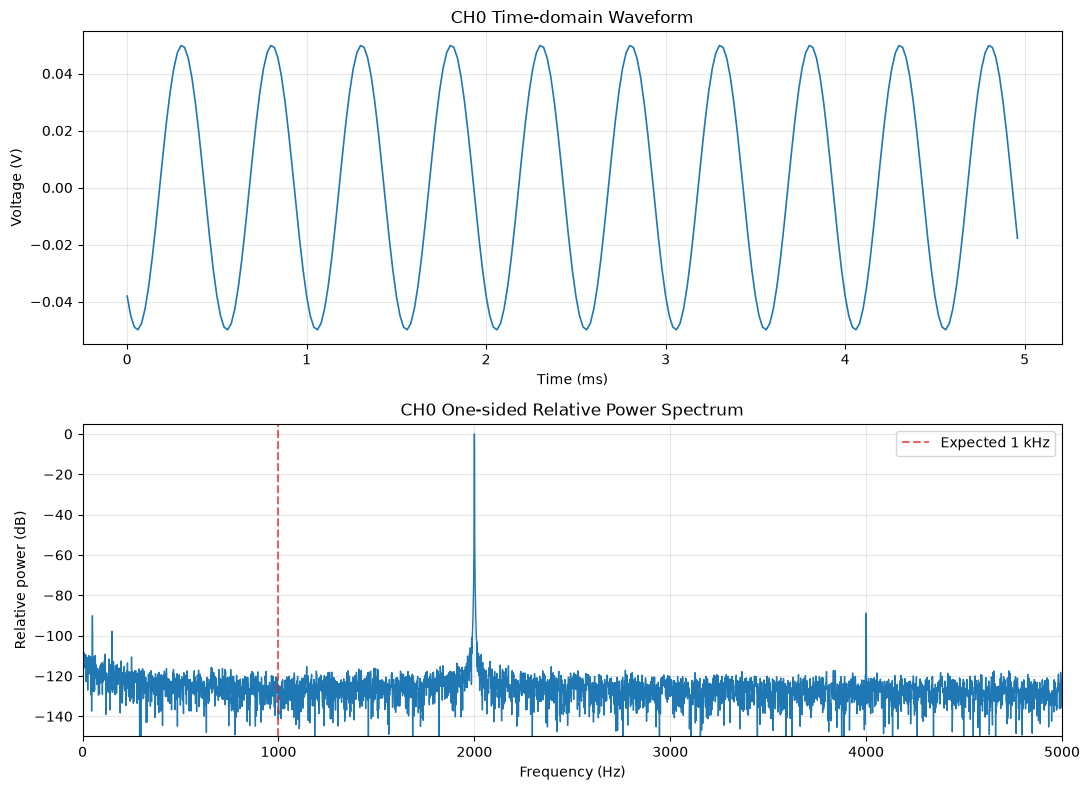

In [20]:
# 时域坐标
time_s = np.arange(len(samples)) / actual_sample_rate

# 单边功率谱；periodogram(..., scaling='spectrum') 的线性单位为 V²。
frequency_hz, power_v2 = periodogram(
    samples,
    fs=actual_sample_rate,
    window="hann",
    detrend="constant",
    return_onesided=True,
    scaling="spectrum",
)

positive_bins = frequency_hz > 0
peak_index = np.flatnonzero(positive_bins)[np.argmax(power_v2[positive_bins])]
peak_frequency = frequency_hz[peak_index]
power_reference = power_v2[peak_index]
power_floor = max(power_reference * 1e-15, np.finfo(float).tiny)
power_db = 10.0 * np.log10(np.maximum(power_v2, power_floor) / power_reference)

ac_rms = np.sqrt(np.mean((samples - np.mean(samples)) ** 2))
sine_vpp_estimate = 2.0 * np.sqrt(2.0) * ac_rms
frequency_resolution = frequency_hz[1] - frequency_hz[0]

print(f"频率间隔：{frequency_resolution:.6f} Hz")
print(f"最大频谱峰：{peak_frequency:.3f} Hz")
print(f"交流 RMS：{ac_rms:.6f} V")
print(f"按正弦波估算：{sine_vpp_estimate:.6f} Vpp")

fig, (ax_time, ax_spectrum) = plt.subplots(2, 1, figsize=(11, 8))

# 显示前 5 ms，约包含 5 个 1 kHz 周期。
time_view_s = 5e-3
time_points = min(len(samples), max(2, int(time_view_s * actual_sample_rate)))
ax_time.plot(time_s[:time_points] * 1e3, samples[:time_points], linewidth=1.2)
ax_time.set_title("CH0 Time-domain Waveform")
ax_time.set_xlabel("Time (ms)")
ax_time.set_ylabel("Voltage (V)")
ax_time.grid(True, alpha=0.3)

ax_spectrum.plot(frequency_hz, power_db, linewidth=1.0)
ax_spectrum.axvline(EXPECTED_FREQUENCY, color="tab:red", linestyle="--", alpha=0.7, label="Expected 1 kHz")
ax_spectrum.set_xlim(0, min(5_000.0, actual_sample_rate / 2.0))
ax_spectrum.set_ylim(-150, 5)
ax_spectrum.set_title("CH0 One-sided Relative Power Spectrum")
ax_spectrum.set_xlabel("Frequency (Hz)")
ax_spectrum.set_ylabel("Relative power (dB)")
ax_spectrum.grid(True, alpha=0.3)
ax_spectrum.legend()

fig.tight_layout()
plt.show()